In [1]:
%pylab inline
import xarray as xr
import cmocean as cmo
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
import gsw
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from sklearn.linear_model import HuberRegressor, LinearRegression

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
### load met data
met_path = "/Volumes/Nikita/PhD/Data/Frankenglider/SBUS/FrankenGlider_Weather_WAM2.csv"
metdf = pd.read_csv(met_path)
metdf['Datetime'] = pd.to_datetime(metdf['TimeStamp']) ## fix date format

In [3]:
## load vegas data files
met_files = sorted(glob.glob(os.path.join("/Volumes/Nikita/PhD/Data/Frankenglider/SBUS/", "Franken*.csv")))

if not met_files:
    raise FileNotFoundError("No Franken*.csv files found in ../data/")
### concatenate data
metdf = pd.concat(
    (pd.read_csv(f) for f in met_files),
    ignore_index=True
)
metdf['Datetime'] = pd.to_datetime(metdf['TimeStamp']) ## fix date format

In [4]:
## load vegas data files
vegas_files = sorted(glob.glob(os.path.join("/Volumes/Nikita/PhD/Data/Frankenglider/SBUS/", "vegas*.csv")))

if not vegas_files:
    raise FileNotFoundError("No vegas*.csv files found in ../data/")
### concatenate data
vegdf = pd.concat(
    (pd.read_csv(f) for f in vegas_files),
    ignore_index=True
)

In [5]:
#date format of the first dataset is (YYYY/MM/DD)
dt1 = pd.to_datetime(
    vegdf['Datetime'],
    format='%Y/%m/%d %H:%M:%S',
    errors='coerce'
)

# date format of the second dataset is (DD-MM-YYYY)
dt2 = pd.to_datetime(
    vegdf['Datetime'],
    format='%d-%m-%Y %H:%M:%S',
    errors='coerce'
)

vegdf['Datetime'] = dt1.fillna(dt2)


In [6]:
vegdf=vegdf[vegdf['Datetime']> pd.to_datetime('2025-12-03')]

In [7]:
def dms_to_dd(arr):
    """
    Convert lon-lat from degrees minutes to decimal degrees
    """
    arr = np.array(arr, dtype=float)
    sign = np.sign(arr) ##  get sign (-/+)
    abs_arr = np.abs(arr) 
    degrees = np.floor(abs_arr / 100)
    minutes = abs_arr % 100
    dd = sign * (degrees + minutes / 60)
    return dd

In [8]:
vegdf["Latitude_dd"] = dms_to_dd(vegdf['Latitude'])
vegdf["Longitude_dd"] = dms_to_dd(vegdf['Longitude'])

In [9]:
vegdf['SP'] = gsw.SP_from_C(vegdf['CTD Conductivity']*10, vegdf['CTD Temp'],p=0)

In [10]:
## bathymentry
isobaths='/Volumes/Nikita/PhD/Data/Bathymetry/gebco.nc'
iso=xr.open_dataset(isobaths)
factor = 2
Iso = iso.coarsen(lon=factor, lat=factor).mean()
minimum = -1000
maximum = 0
mask = (Iso.elevation > minimum) & (Iso.elevation < maximum)

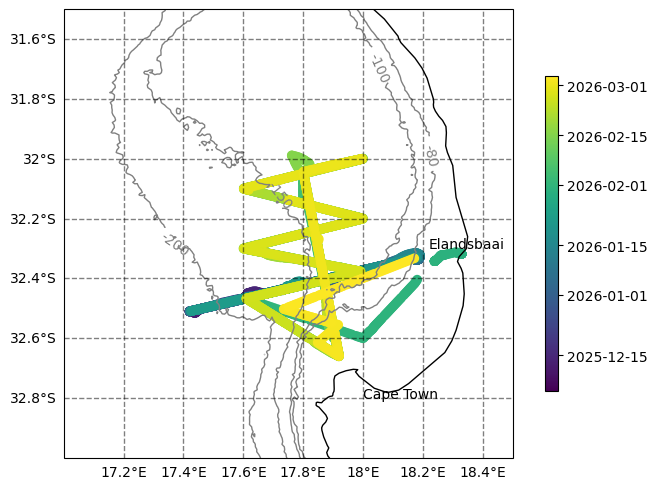

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.dates as mdates

fig = plt.figure(figsize=(7, 5))
ax = plt.axes(projection=ccrs.PlateCarree())



# Convert datetime to matplotlib numbers
time_num = mdates.date2num(vegdf['Datetime'])

sc = ax.scatter(vegdf["Longitude_dd"],
    vegdf["Latitude_dd"],
    c=time_num,
    transform=ccrs.PlateCarree()
)

# Proper colorbar formatting
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, aspect=25, pad=0.05)

cbar.locator = mdates.AutoDateLocator()
cbar.formatter = mdates.DateFormatter('%Y-%m-%d')
cbar.update_ticks()

# Remove default ticks
ax.set_xticks([])
ax.set_yticks([])

# Map features
ax.coastlines()
ax.set_extent([17, 18.5, -33, -31.5])

# Contours
cs = ax.contour(
    Iso.lon, Iso.lat, Iso.elevation,
    levels=[-200,-150,-100,-80],
    colors='gray',
    linewidths=1,linestyles='-',
    transform=ccrs.PlateCarree()  # important for Cartopy
)

# List of (x, y) positions where you want labels
label_positions = [(17.2, -32.5), (17.8, -32.0), (18.0, -31.7),(18.2, -32)]

ax.clabel(
    cs,
    inline=True,
    fontsize=10,
    fmt='%d',
    manual=label_positions
)
gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=1,
    color='k',
    alpha=0.5,
    linestyle='--'
)
gridlines.right_labels = False
gridlines.top_labels = False
gridlines.xlabel_style = {'size': 10}
gridlines.ylabel_style = {'size': 10}

ax.text(18,-32.8,'Cape Town')
ax.text(18.22,-32.3,'Elandsbaai')

plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Frankenglider/SBUS/surface_map_march.png')
plt.show()


In [17]:
vegdf['pH'] = vegdf['PH Ext']
vegdf.loc[~vegdf['PH Ext'].between(7, 9), 'pH'] = np.nan

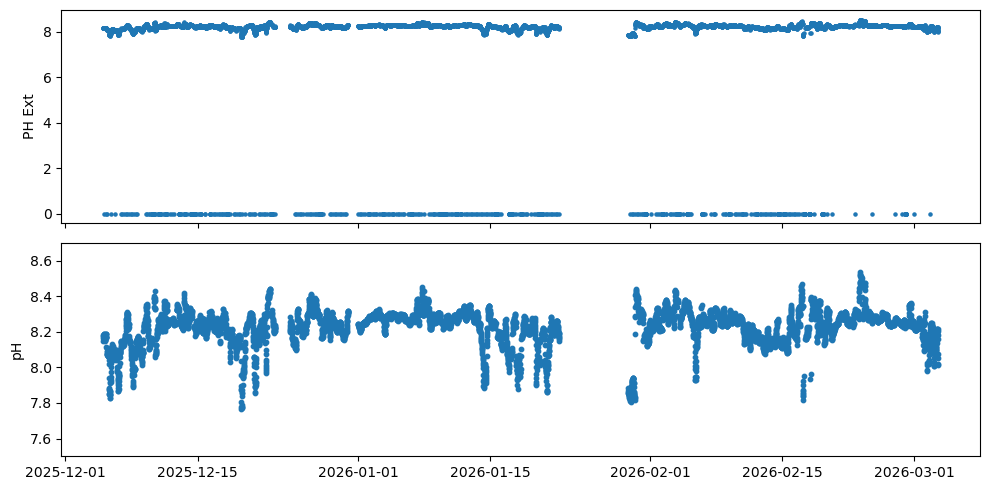

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].scatter(vegdf['Datetime'], vegdf['PH Ext'], s=5)
ax[0].set_ylabel('PH Ext')

#ax[0].plot(vegdf['Datetime'], vegdf['pH'])
ax[1].scatter(vegdf['Datetime'], vegdf['pH'], s=10)
ax[1].set_ylim(7.5, 8.7)
ax[1].set_ylabel('pH')

plt.tight_layout()

In [19]:
def huber_regression(x,y,xlab,ylab,tt):
    
    valid = ~np.isnan(x) & ~np.isnan(y) ## remove nans
    X_clean = x[valid].reshape(-1, 1)
    y_clean = y[valid]

    if len(X_clean) < 2:
        raise ValueError("Not enough valid data points after removing NaNs.")

    huber = HuberRegressor(epsilon=1.8)
    huber.fit(X_clean, y_clean)
    
    # Get inliers
    mask = huber.outliers_ == False  # True for inliers
    X_in = X_clean[mask]
    y_in = y_clean[mask]
    y_pred = huber.predict(X_in)
    r2 = huber.score(X_in, y_in)
    
    # Plot
    fig,ax = plt.subplots(1,1,figsize=(5,4))
    ax.scatter(X_clean[~mask], y_clean[~mask], color='lightgray', label='Outliers', marker='x')
    ax.scatter(X_in, y_in, color='blue', label='Inliers')
    ax.plot(X_in, y_pred, color='black', lw=2, label=f'Fit\n$R^2$={r2:.2f}')
    ax.text(7.8,300,f'y = {-993}x + {8519}',fontstyle='italic')
    
    ax.set_title(tt)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_ylim(150,1100)
    ax.legend()
    ax.grid(True)
    print(f"Slope: {huber.coef_[0]}")
    print(f"Intercept: {huber.intercept_}")
    print(f"R^2 Score: {huber.score(X_clean, y_clean)}")
    #plt.savefig('/Volumes/Nikita/PhD//waveglider/figures/pHvsco2.png')

    return 

Slope: -993.009067732394
Intercept: 8525.448904481333
R^2 Score: -0.03448580140334778


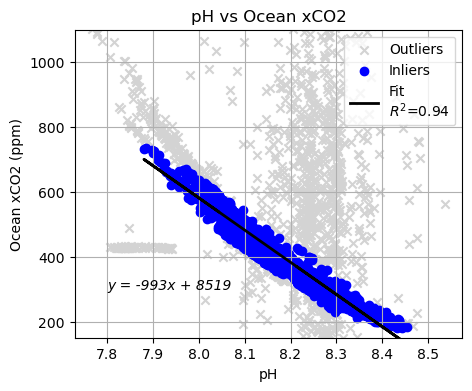

In [22]:
huber_regression(vegdf['pH'].values,vegdf['Ocean CO2 Ave'].values,'pH','Ocean xCO2 (ppm)','pH vs Ocean xCO2')

In [21]:
derived_xco2 = -993.0961775728762*vegdf['pH'].values+8519.40718042995

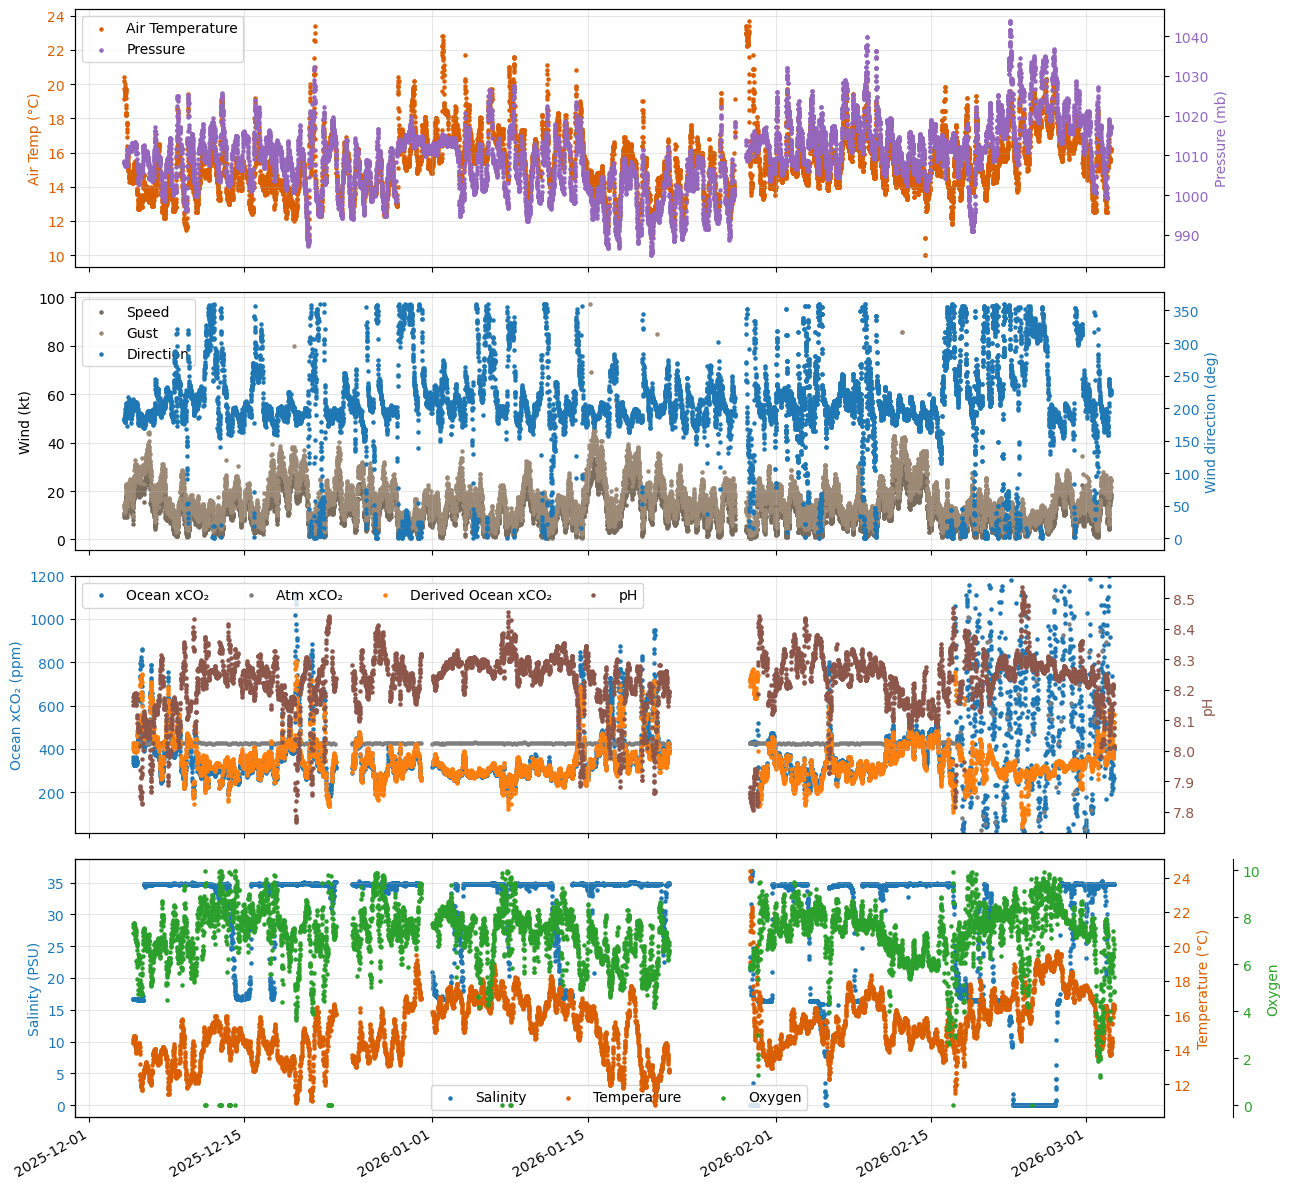

In [23]:
fig, ax = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# ==========================================================
# 1) Air Temperature + Pressure
# ==========================================================
sc1 = ax[0].scatter(metdf['Datetime'],
                    metdf['Temperature(degC)'],
                    c='#D95F02', s=5)

ax[0].set_ylabel('Air Temp (°C)', color='#D95F02')
ax[0].tick_params(axis='y', labelcolor='#D95F02')

ax0_r = ax[0].twinx()
sc2 = ax0_r.scatter(metdf['Datetime'],
                    metdf['Pressure(mb)'],
                    c='tab:purple', s=5)

ax0_r.set_ylabel('Pressure (mb)', color='tab:purple')
ax0_r.tick_params(axis='y', labelcolor='tab:purple')

ax[0].legend([sc1, sc2], ['Air Temperature', 'Pressure'],
             loc='upper left', ncol=1)

# ==========================================================
# 2) Wind Speed + Gust (colored by direction)
# ==========================================================
sc1 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Speed(kt)'],
                    c='#7A6C5D',
                    s=5)

sc2 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Gust Speed(kt)'],
                    c= '#9C8A77',
                    s=5)

ax1_r = ax[1].twinx()
sc3 = ax1_r.scatter(metdf['Datetime'],
                    metdf['Wind Direction'],
                    c='#1F78B4', s=5)

ax1_r.set_ylabel('Wind direction (deg)', color='#1F78B4')
ax1_r.tick_params(axis='y', labelcolor='#1F78B4')


ax[1].set_ylabel('Wind (kt)')
ax[1].legend([sc1,sc2,sc3], ['Speed', 'Gust','Direction'],
             loc='upper left', ncol=1)

# ==========================================================
# 3) Ocean xCO2 + Atmos xCO2
# ==========================================================
sc1 = ax[2].scatter(vegdf['Datetime'],
                    vegdf['Ocean CO2 Ave'],
                    c='tab:blue', s=5)
sc2 = ax[2].scatter(vegdf['Datetime'],
                    vegdf['Atmosphere CO2 Ave'],
                    c='tab:gray', s=5)
sc3 = ax[2].scatter(vegdf['Datetime'],
                    derived_xco2,
                    c='tab:orange', s=5)

ax[2].set_ylabel('Ocean xCO₂ (ppm)', color='tab:blue')
ax[2].tick_params(axis='y', labelcolor='tab:blue')


ax[2].set_ylim(10,1200)

ax2_r = ax[2].twinx()

sc4 = ax2_r.scatter(vegdf['Datetime'],
                     vegdf['pH'],
                     c='tab:brown', s=5)
ax2_r.set_ylabel('pH', color='tab:brown')
ax2_r.tick_params(axis='y', labelcolor='tab:brown')

ax[2].legend([sc1, sc2, sc3, sc4], ['Ocean xCO₂', 'Atm xCO₂','Derived Ocean xCO₂', 'pH'],loc='upper left', ncol=4)

# ==========================================================
# 4) Salinity + Temp + Oxygen
# ==========================================================
sc1 = ax[3].scatter(vegdf['Datetime'],
                    vegdf['SP'],
                    c='tab:blue', s=5)

ax[3].set_ylabel('Salinity (PSU)', color='tab:blue')
ax[3].tick_params(axis='y', labelcolor='tab:blue')

ax3_r1 = ax[3].twinx()
sc2 = ax3_r1.scatter(vegdf['Datetime'],
                     vegdf['CTD Temp'],
                     c='#D95F02', s=5)

ax3_r1.set_ylabel('Temperature (°C)', color='#D95F02')
ax3_r1.tick_params(axis='y', labelcolor='#D95F02')

ax3_r2 = ax[3].twinx()
ax3_r2.spines['right'].set_position(('outward', 50))

sc3 = ax3_r2.scatter(vegdf['Datetime'],
                     vegdf['O2 Calculated'],
                     c='tab:green', s=5)

ax3_r2.set_ylabel('Oxygen', color='tab:green')
ax3_r2.tick_params(axis='y', labelcolor='tab:green')

ax[3].legend([sc1, sc2, sc3],
             ['Salinity', 'Temperature', 'Oxygen'],
             loc='lower center', ncol=3)

# ==========================================================
for a in ax:
    a.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Frankenglider/SBUS/wg_variables.png')
plt.show()


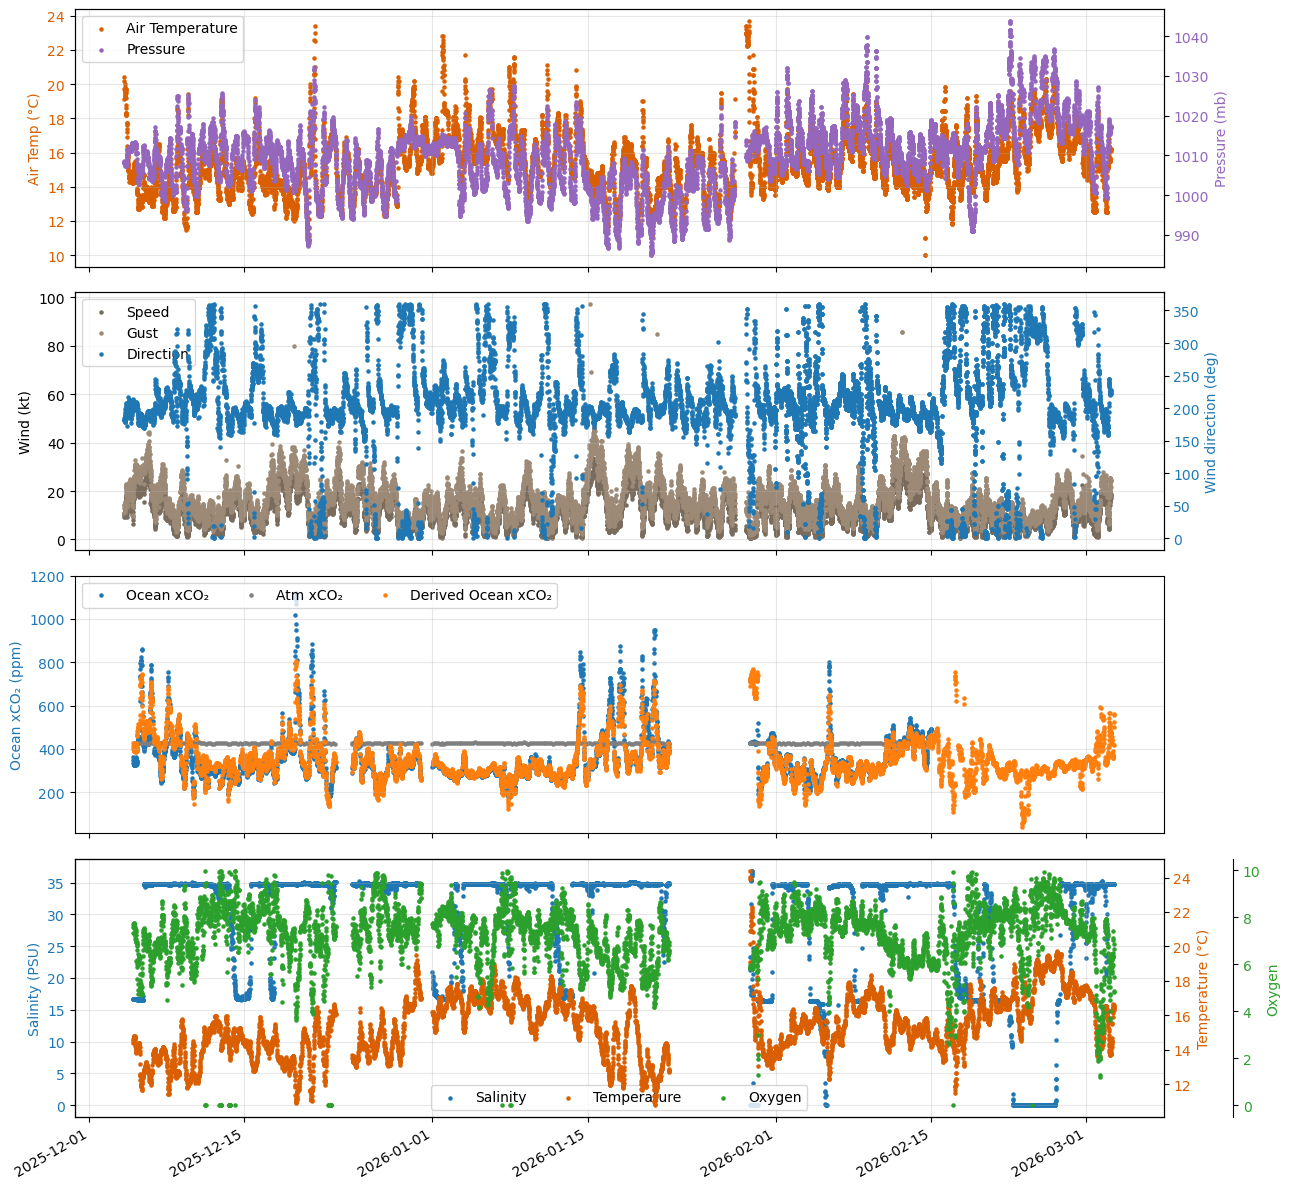

In [24]:
fig, ax = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

# ==========================================================
# 1) Air Temperature + Pressure
# ==========================================================
sc1 = ax[0].scatter(metdf['Datetime'],
                    metdf['Temperature(degC)'],
                    c='#D95F02', s=5)

ax[0].set_ylabel('Air Temp (°C)', color='#D95F02')
ax[0].tick_params(axis='y', labelcolor='#D95F02')

ax0_r = ax[0].twinx()
sc2 = ax0_r.scatter(metdf['Datetime'],
                    metdf['Pressure(mb)'],
                    c='tab:purple', s=5)

ax0_r.set_ylabel('Pressure (mb)', color='tab:purple')
ax0_r.tick_params(axis='y', labelcolor='tab:purple')

ax[0].legend([sc1, sc2], ['Air Temperature', 'Pressure'],
             loc='upper left', ncol=1)

# ==========================================================
# 2) Wind Speed + Gust (colored by direction)
# ==========================================================
sc1 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Speed(kt)'],
                    c='#7A6C5D',
                    s=5)

sc2 = ax[1].scatter(metdf['Datetime'],
                    metdf['Wind Gust Speed(kt)'],
                    c= '#9C8A77',
                    s=5)

ax1_r = ax[1].twinx()
sc3 = ax1_r.scatter(metdf['Datetime'],
                    metdf['Wind Direction'],
                    c='#1F78B4', s=5)

ax1_r.set_ylabel('Wind direction (deg)', color='#1F78B4')
ax1_r.tick_params(axis='y', labelcolor='#1F78B4')


ax[1].set_ylabel('Wind (kt)')
ax[1].legend([sc1,sc2,sc3], ['Speed', 'Gust','Direction'],
             loc='upper left', ncol=1)

# ==========================================================
# 3) Ocean xCO2 + Atmos xCO2
# ==========================================================
indexes = np.where(vegdf['Datetime']<pd.to_datetime('2026-02-15'))[0]
sc1 = ax[2].scatter(vegdf['Datetime'].iloc[indexes],
                    vegdf['Ocean CO2 Ave'].iloc[indexes],
                    c='tab:blue', s=5)
sc2 = ax[2].scatter(vegdf['Datetime'].iloc[indexes],
                    vegdf['Atmosphere CO2 Ave'].iloc[indexes],
                    c='tab:gray', s=5)
sc3 = ax[2].scatter(vegdf['Datetime'],
                    derived_xco2,
                    c='tab:orange', s=5)

ax[2].set_ylabel('Ocean xCO₂ (ppm)', color='tab:blue')
ax[2].tick_params(axis='y', labelcolor='tab:blue')


ax[2].set_ylim(10,1200)

ax[2].legend([sc1, sc2, sc3], ['Ocean xCO₂', 'Atm xCO₂','Derived Ocean xCO₂'],loc='upper left', ncol=4)

# ==========================================================
# 4) Salinity + Temp + Oxygen
# ==========================================================
sc1 = ax[3].scatter(vegdf['Datetime'],
                    vegdf['SP'],
                    c='tab:blue', s=5)

ax[3].set_ylabel('Salinity (PSU)', color='tab:blue')
ax[3].tick_params(axis='y', labelcolor='tab:blue')

ax3_r1 = ax[3].twinx()
sc2 = ax3_r1.scatter(vegdf['Datetime'],
                     vegdf['CTD Temp'],
                     c='#D95F02', s=5)

ax3_r1.set_ylabel('Temperature (°C)', color='#D95F02')
ax3_r1.tick_params(axis='y', labelcolor='#D95F02')

ax3_r2 = ax[3].twinx()
ax3_r2.spines['right'].set_position(('outward', 50))

sc3 = ax3_r2.scatter(vegdf['Datetime'],
                     vegdf['O2 Calculated'],
                     c='tab:green', s=5)

ax3_r2.set_ylabel('Oxygen', color='tab:green')
ax3_r2.tick_params(axis='y', labelcolor='tab:green')

ax[3].legend([sc1, sc2, sc3],
             ['Salinity', 'Temperature', 'Oxygen'],
             loc='lower center', ncol=3)

# ==========================================================
for a in ax:
    a.grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Frankenglider/SBUS/wg_variablesv2.png')
plt.show()

### Zig-Zag sampling

In [25]:
veg_subset= vegdf[dt2.notna()]
#veg_subset = veg_subset.set_index('Datetime')

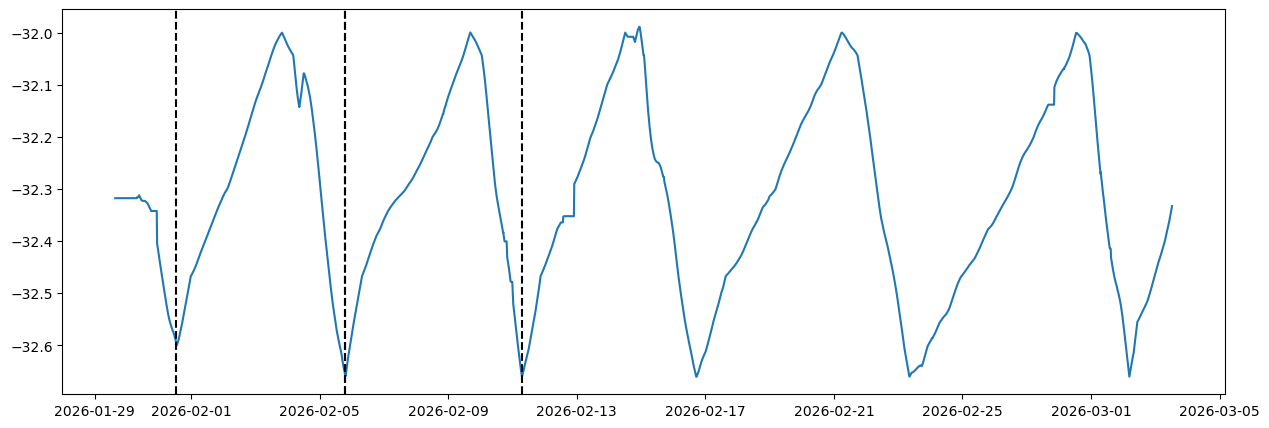

In [26]:
plt.figure(figsize=(15,5))
plt.plot(veg_subset['Datetime'],veg_subset['Latitude_dd'])
plt.axvline(x=pd.to_datetime('2026-01-31 12:40:52'),c='k',linestyle='--')
plt.axvline(x=pd.to_datetime('2026-02-05 18:40:00'),c='k',linestyle='--')
plt.axvline(x=pd.to_datetime('2026-02-05 18:40:00'),c='k',linestyle='--')
plt.axvline(x=pd.to_datetime('2026-02-11 06:40:00'),c='k',linestyle='--')

In [27]:
start = pd.to_datetime('2026-01-31 12:40:52')
end   = pd.to_datetime('2026-02-05 18:40:00')

vegA = veg_subset[(vegdf['Datetime'] >= start) &
                   (vegdf['Datetime'] <= end)]

start = pd.to_datetime('2026-02-05 18:40:00')
end   = pd.to_datetime('2026-02-11 06:40:00')

vegB = veg_subset[(vegdf['Datetime'] >= start) &
                   (vegdf['Datetime'] <= end)]

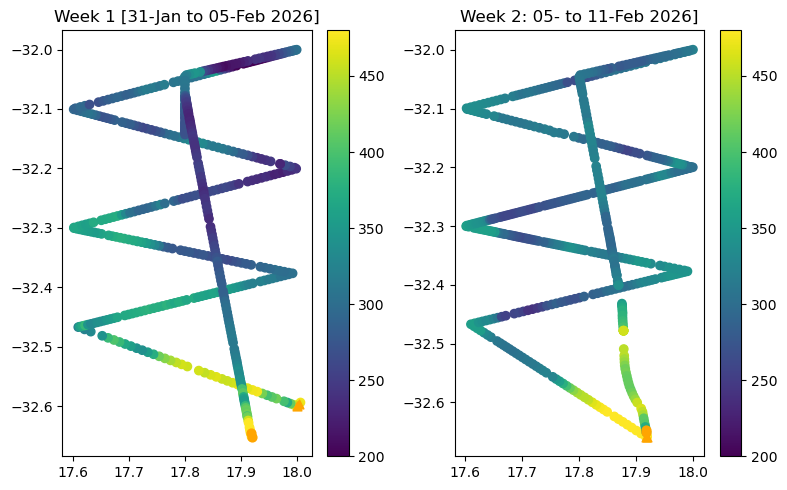

In [28]:
fig,ax = plt.subplots(1,2,figsize=(8,5))


################### 31-Jan to 5-Feb 2026######################
sc1=ax[0].scatter(vegA['Longitude_dd'],vegA['Latitude_dd'],c=vegA['Ocean CO2 Ave'],vmin = 200,vmax=480)
ax[0].scatter(vegA['Longitude_dd'].iloc[-1],vegA['Latitude_dd'].iloc[-1],c='orange',s=40)
ax[0].scatter(vegA['Longitude_dd'].iloc[-2],vegA['Latitude_dd'].iloc[-2],c='orange',s=40)

ax[0].scatter(vegA['Longitude_dd'].iloc[1],vegA['Latitude_dd'].iloc[1],c='orange',s=40,marker='^')
ax[0].scatter(vegA['Longitude_dd'].iloc[2],vegA['Latitude_dd'].iloc[2],c='orange',s=40,marker='^')
ax[0].set_title('Week 1 [31-Jan to 05-Feb 2026]')

plt.colorbar(sc1,ax=ax[0])

################### 05-Feb to 11-Feb 2026######################
sc1=ax[1].scatter(vegB['Longitude_dd'],vegB['Latitude_dd'],c=vegB['Ocean CO2 Ave'],vmin = 200,vmax=480)
ax[1].scatter(vegB['Longitude_dd'].iloc[-1],vegB['Latitude_dd'].iloc[-1],c='orange',s=40)
ax[1].scatter(vegB['Longitude_dd'].iloc[-2],vegB['Latitude_dd'].iloc[-2],c='orange',s=40)

ax[1].scatter(vegB['Longitude_dd'].iloc[1],vegB['Latitude_dd'].iloc[1],c='orange',s=40,marker='^')
ax[1].scatter(vegB['Longitude_dd'].iloc[2],vegB['Latitude_dd'].iloc[2],c='orange',s=40,marker='^')
ax[1].set_title('Week 2: 05- to 11-Feb 2026]')
plt.colorbar(sc1,ax=ax[1])

plt.tight_layout()

In [29]:
xdA = np.array(vegA['Longitude_dd'])
ydA = np.array(vegA['Latitude_dd'])
zdA = np.array(vegA['Ocean CO2 Ave'])

xiA = np.linspace(np.min(xdA), np.max(xdA), 20)
yiA = np.linspace(np.min(ydA), np.max(ydA), 20)

XA,YA = np.meshgrid(xiA,yiA)

points = np.column_stack((xdA, ydA))

ZA = griddata(points, zdA, (XA, YA), method='linear')

In [30]:
xdB = np.array(vegB['Longitude_dd'])
ydB = np.array(vegB['Latitude_dd'])
zdB = np.array(vegB['Ocean CO2 Ave'])

xiB = np.linspace(np.min(xdB), np.max(xdB), 20)
yiB = np.linspace(np.min(ydB), np.max(ydB), 20)

XB,YB = np.meshgrid(xiB,yiB)

points = np.column_stack((xdB, ydB))

ZB = griddata(points, zdB, (XB, YB), method='linear')

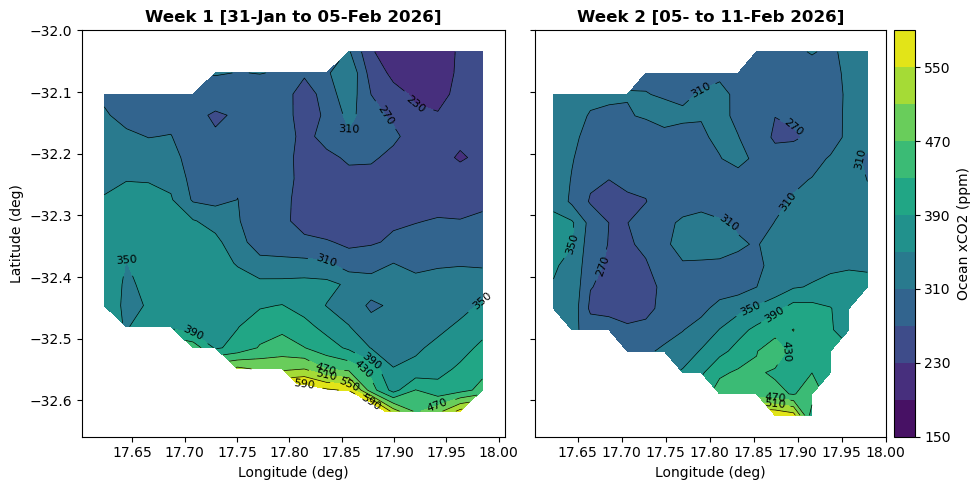

In [31]:
levels = np.arange(150, 601, 40)

fig, ax = plt.subplots(1, 2, figsize=(10,5),sharey=True)

################### Week 1 ######################
c1 = ax[0].contourf(XA, YA, ZA, levels=levels)
cs1 = ax[0].contour(XA, YA, ZA, levels=levels, colors='k', linewidths=0.5)

ax[0].clabel(cs1, inline=True, fontsize=8)
ax[0].set_title('Week 1 [31-Jan to 05-Feb 2026]',fontweight='bold')
ax[0].set_ylabel('Latitude (deg)')
ax[0].set_xlabel('Longitude (deg)')

################### Week 2 ######################
c2 = ax[1].contourf(XB, YB, ZB, levels=levels)
cs2 = ax[1].contour(XB, YB, ZB, levels=levels, colors='k', linewidths=0.5)

ax[1].clabel(cs2, inline=True, fontsize=8)
ax[1].set_title('Week 2 [05- to 11-Feb 2026]',fontweight='bold')
ax[1].set_xlabel('Longitude (deg)')

# Shared colorbar
cbar = fig.colorbar(c1, ax=ax[1], pad=0.02)
cbar.set_label('Ocean xCO2 (ppm)')

plt.tight_layout()
plt.show()


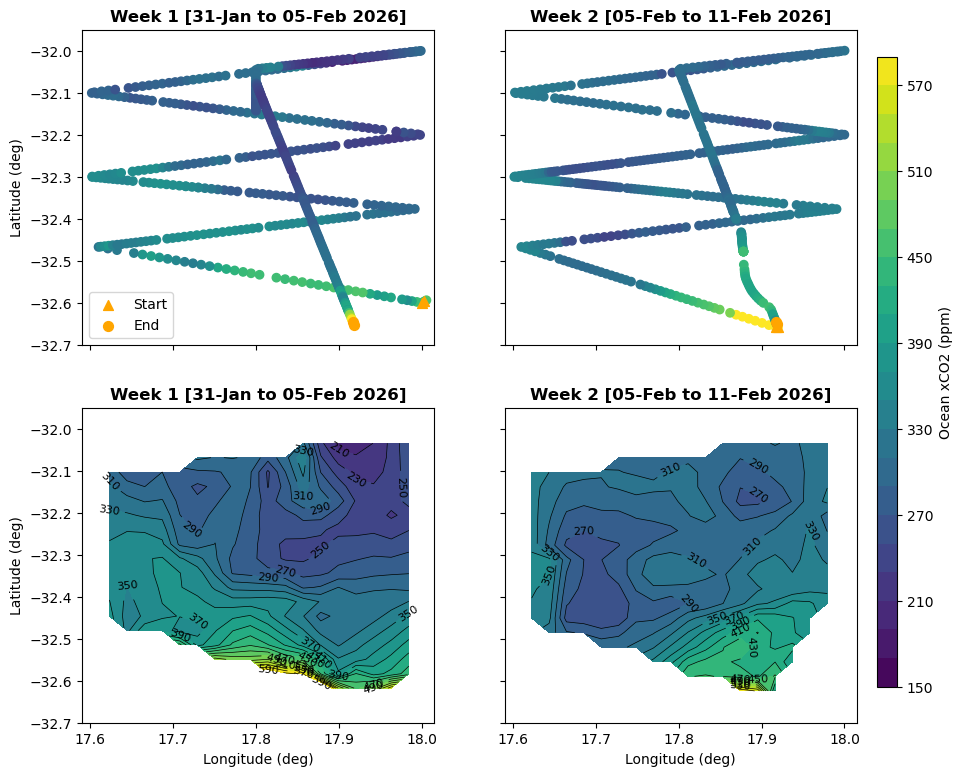

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# ------------------------
# Contour levels
# ------------------------
levels = np.arange(150, 601, 20)  # 150 to 600 ppm

# ------------------------
# Create figure
# ------------------------
fig, ax = plt.subplots(2, 2, figsize=(10,9),sharex=True,sharey=True)
ax = ax.flatten()  # flatten to 1D array for easy indexing: ax[0], ax[1], ax[2], ax[3]

# ========================
# Top-left: Week 1 scatter
# ========================
sc0 = ax[0].scatter(
    vegA['Longitude_dd'], vegA['Latitude_dd'],
    c=vegA['Ocean CO2 Ave'], vmin=150, vmax=600, cmap='viridis'
)
# Start points (triangles)
ax[0].scatter(
    vegA['Longitude_dd'].iloc[1:3], vegA['Latitude_dd'].iloc[1:3],
    c='orange', s=50, marker='^', label='Start'
)
# End points (circles)
ax[0].scatter(
    vegA['Longitude_dd'].iloc[-2:], vegA['Latitude_dd'].iloc[-2:],
    c='orange', s=50, label='End'
)
ax[0].set_title('Week 1 [31-Jan to 05-Feb 2026]', fontweight='bold')
ax[0].set_ylabel('Latitude (deg)')
ax[0].set_ylim(-32.7,-31.95)
ax[0].set_xlim(17.59,18.015)
ax[0].legend(loc='lower left')

# ========================
# Top-right: Week 2 scatter
# ========================
sc1 = ax[1].scatter(
    vegB['Longitude_dd'], vegB['Latitude_dd'],
    c=vegB['Ocean CO2 Ave'], vmin=150, vmax=600, cmap='viridis'
)
ax[1].scatter(
    vegB['Longitude_dd'].iloc[1:3], vegB['Latitude_dd'].iloc[1:3],
    c='orange', s=50, marker='^', label='Start'
)
ax[1].scatter(
    vegB['Longitude_dd'].iloc[-2:], vegB['Latitude_dd'].iloc[-2:],
    c='orange', s=50, label='End'
)
ax[1].set_title('Week 2 [05-Feb to 11-Feb 2026]', fontweight='bold')


# ========================
# Bottom-left: Week 1 contour
# ========================
c2 = ax[2].contourf(XA, YA, ZA, levels=levels, cmap='viridis')
cs2 = ax[2].contour(XA, YA, ZA, levels=levels, colors='k', linewidths=0.5)
ax[2].clabel(cs2, inline=True, fontsize=8)
ax[2].set_title('Week 1 [31-Jan to 05-Feb 2026]', fontweight='bold')
ax[2].set_xlabel('Longitude (deg)')
ax[2].set_ylabel('Latitude (deg)')

# ========================
# Bottom-right: Week 2 contour
# ========================
c3 = ax[3].contourf(XB, YB, ZB, levels=levels, cmap='viridis')
cs3 = ax[3].contour(XB, YB, ZB, levels=levels, colors='k', linewidths=0.5)
ax[3].clabel(cs3, inline=True, fontsize=8)
ax[3].set_title('Week 2 [05-Feb to 11-Feb 2026]', fontweight='bold')
ax[3].set_xlabel('Longitude (deg)')

# ------------------------
# Shared colorbar for all plots
# ------------------------
# x-position, y-position, width, height
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
cbar = fig.colorbar(c2, cax=cbar_ax)
cbar.set_label('Ocean xCO2 (ppm)')
#plt.tight_layout()
plt.savefig('/Volumes/Nikita/PhD/Figures/Frankenglider/SBUS/pco2_surface_map.png')
plt.show()
